# Import necessary libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import sys
sys.path.append("..")      
from src.load_data import load_raw_data

### Load data

In [14]:
df = load_raw_data("data/raw/data.csv")

 Loaded data: 541,909 rows, 8 columns


### BASIC LOOKUP

In [15]:
print("shape:", df.shape)

shape: (541909, 8)


In [16]:
print("\n Column names:", df.columns.tolist())


 Column names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [17]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [18]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### MISSING VALUES

In [22]:
missing = pd.DataFrame({
    "count":df.isnull().sum(),
    "percent" :(df.isnull().sum() /len(df)*100).round(2)
                })

missing=missing[missing["count"]>0]

missing.sort_values("percent", ascending =False)

,count,percent
CustomerID,135080,24.93
Description,1454,0.27


### TARGET VARIABLE

In [24]:
plt.figure(figsize =(12,4))
# figsize=(width, height) in inches
# (12, 4) = wide and short — good for distributions

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Axes: >

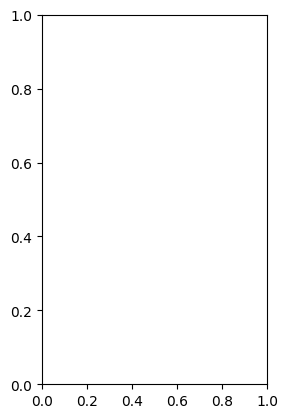

In [25]:
plt.subplot(1, 2, 1)
# subplot(rows, cols, position)
# (1, 2, 1) = 1 row, 2 columns, first position
# We want two charts side by side

In [31]:
print(df[df["Quantity"] < 0].head())

    InvoiceNo StockCode                       Description  Quantity  \
141   C536379         D                          Discount        -1   
154   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   

         InvoiceDate  UnitPrice  CustomerID         Country  order_value  
141   12/1/2010 9:41      27.50     14527.0  United Kingdom       -27.50  
154   12/1/2010 9:49       4.65     15311.0  United Kingdom        -4.65  
235  12/1/2010 10:24       1.65     17548.0  United Kingdom       -19.80  
236  12/1/2010 10:24       0.29     17548.0  United Kingdom        -6.96  
237  12/1/2010 10:24       0.29     17548.0  United Kingdom        -6.96  


In [32]:
print(df[df["UnitPrice"] <= 0].head())

     InvoiceNo StockCode Description  Quantity      InvoiceDate  UnitPrice  \
622     536414     22139         NaN        56  12/1/2010 11:52        0.0   
1970    536545     21134         NaN         1  12/1/2010 14:32        0.0   
1971    536546     22145         NaN         1  12/1/2010 14:33        0.0   
1972    536547     37509         NaN         1  12/1/2010 14:33        0.0   
1987    536549    85226A         NaN         1  12/1/2010 14:34        0.0   

      CustomerID         Country  order_value  
622          NaN  United Kingdom          0.0  
1970         NaN  United Kingdom          0.0  
1971         NaN  United Kingdom          0.0  
1972         NaN  United Kingdom          0.0  
1987         NaN  United Kingdom          0.0  


In [33]:
df = df[df["Quantity"] > 0]         # remove returns
df = df[df["UnitPrice"] > 0]        # remove bad prices
df["order_value"] = df["Quantity"] * df["UnitPrice"]

<Axes: >

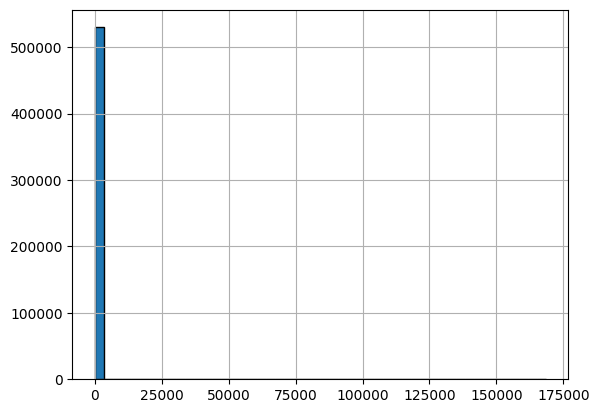

In [34]:
df["order_value"].hist(bins=50, edgecolor="black")
# bins=50 = divide data into 50 buckets
# edgecolor="black" = black outline on each bar
# more bins = more detail but noisier

<Axes: >

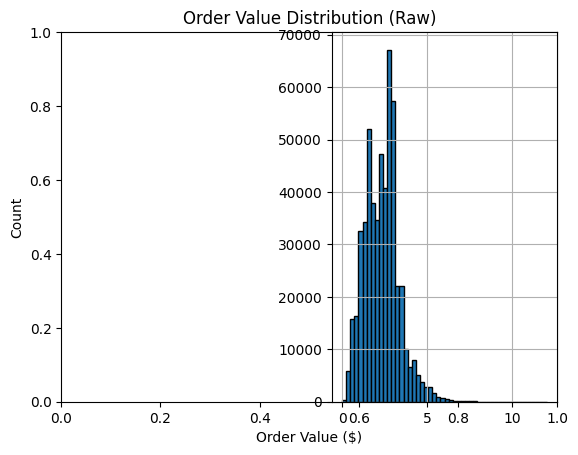

In [35]:
plt.title("Order Value Distribution (Raw)")
plt.xlabel("Order Value ($)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
np.log1p(df["order_value"]).hist(bins=50, edgecolor="black")

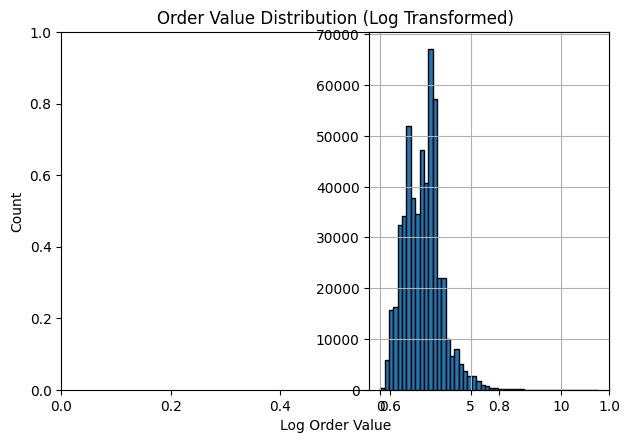

In [39]:
plt.title("Order Value Distribution (Log Transformed)")
plt.xlabel("Log Order Value")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
np.log1p(df["order_value"]).hist(bins=50, edgecolor="black")
plt.tight_layout()
# prevents charts from overlapping each other
plt.show()

### FEATURE DISTRIBUTIONS

In [40]:
numeric_cols = ["customer_age", "days_since_last_order",
                "total_orders", "avg_order_value"]

KeyError: 'customer_age'

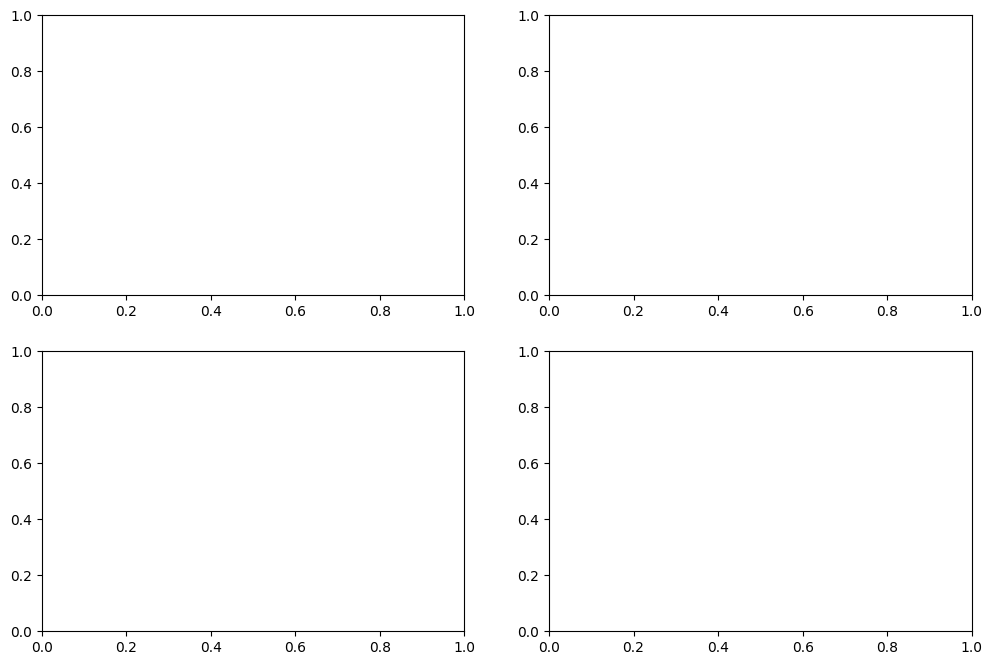

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    # enumerate gives both index i AND value col
    # i=0, col="customer_age"
    # i=1, col="days_since_last_order" etc.

    axes[i].hist(df[col].dropna(), bins=30, alpha=0.7)
    # .dropna() removes NaN values before plotting
    # without this, hist throws an error on missing values
    # alpha=0.7 = 70% opacity — slight transparency looks better

    axes[i].axvline(df[col].mean(), color="red",
                    linestyle="--", label="mean")
    # axvline = vertical line at x position
    # we draw it at the mean
    # linestyle="--" = dashed line
    # label= will show in legend

    axes[i].axvline(df[col].median(), color="green",
                    linestyle="--", label="median")
    # second line at median
    # if mean and median are far apart = skewed distribution

    axes[i].legend()
    # shows the labels we defined above

plt.tight_layout()
plt.show()